# Variogram analysis for COCO2 synthetic dataset new version

notebook created based on Laia's compute_cov_matrix.ipynb

In [1]:
import os

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
import pandas as pd
import sys
sys.path.append('../src/')
from tqdm import tqdm
import warnings

from pyproj import CRS, Transformer
from geopy.distance import geodesic
from skgstat import Variogram, DirectionalVariogram

warnings.filterwarnings("ignore", message="Warning: converting a masked element to nan.")

import auxiliar_functions as aux

In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt

def plot_data(aoi, lon, lat, date, data1, title1, label1, 
              data2=None, title2=None, label2=None, 
              projection=ccrs.PlateCarree(), savefig=None, title=None):
    """
    Plots the data on a map.

    """
    if data2 is None:
        fig, ax = plt.subplots(figsize=(12, 8), edgecolor='k', subplot_kw={'projection': projection})
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS)
        ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.4, linestyle='--')
        ax.set_extent(aoi)
        ax.set_title(title1, fontsize=18)
        
        if len(data1.shape) == 1:
            # use scatter plot
            sc = ax.scatter(lon, lat, c=data1, cmap='viridis', transform=projection, s=0.85, alpha=1)
            #plt.colorbar(sc, orientation='vertical')
            plt.colorbar(sc, orientation='horizontal') #maija's addition
        else:
            # use pcolormesh
            mesh = ax.pcolormesh(lon, lat, data1, cmap='viridis', transform=projection, alpha=0.7)
            cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.05)
            cbar.set_label(label1)
    else:
        fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': projection}, figsize=(16, 6), constrained_layout=True)

        for ax in [ax1, ax2]:
            ax.add_feature(cfeature.COASTLINE)
            ax.add_feature(cfeature.BORDERS)
            ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.4, linestyle='--')
            ax.set_extent(aoi)

        if len(data1.shape) == 1:
            # use scatter plot
            sc1 = ax1.scatter(lon, lat, c=data1, cmap='viridis', transform=projection, s=0.85, alpha=1)
            plt.colorbar(sc1, ax=ax1, orientation='horizontal', label=label1)

            sc2 = ax2.scatter(lon, lat, c=data2, cmap='viridis', transform=projection, s=0.85, alpha=1)
            plt.colorbar(sc2, ax=ax2, orientation='horizontal', label=label2)
        else:
            # use pcolormesh
            mesh1 = ax1.pcolormesh(lon, lat, data1, cmap='viridis', transform=projection, alpha=0.7)
            cbar1 = plt.colorbar(mesh1, ax=ax1, orientation='horizontal', pad=0.05)
            cbar1.set_label(label1)

            mesh2 = ax2.pcolormesh(lon, lat, data2, cmap='viridis', transform=projection, alpha=0.7)
            cbar2 = plt.colorbar(mesh2, ax=ax2, orientation='horizontal', pad=0.05)
            cbar2.set_label(label2)

        ax1.set_title(title1, fontsize=18)
        ax2.set_title(title2, fontsize=18)

        #fig.suptitle(f"Data on {date[0:10]}", fontsize=18)
        if title is not None:
            fig.suptitle(title, fontsize=18)

    if savefig is not None:
        plt.savefig(savefig)

    #plt.tight_layout()    
    plt.show()

Maija's edit: for 1-month period

# Load the gridded uncertainties for a certain month

Load uncertainties that calculated earlier

In [ ]:
date = 0
aoi = [-15, 40, 30, 60] 

monthid = 6

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

month = month_names[monthid]
DATA_PATH = '/home/pietaril/Documents/data/CO2M_simulations/regridded_monthly_uncertainties/'
uncertainties_1month = np.load(os.path.join(DATA_PATH, f'rg_uncert_{month}.npy'))



# mask with xco2 in the months with uncertainties in places where there aren't observations
if month == "Jul":
    XCO2_PATH = '/home/pietaril/Documents/data/CO2M_simulations/regridded_monthly_xco2/'
    xco2_1month = np.load(os.path.join(XCO2_PATH, f'rg_xco2_{month}.npy'))
    uncertainties_1month[np.isnan(xco2_1month)] = np.nan


In [7]:
len(uncertainties_1month.shape)

1

In [9]:
xco2_1month

array([nan, nan, nan, ..., nan, nan, nan])

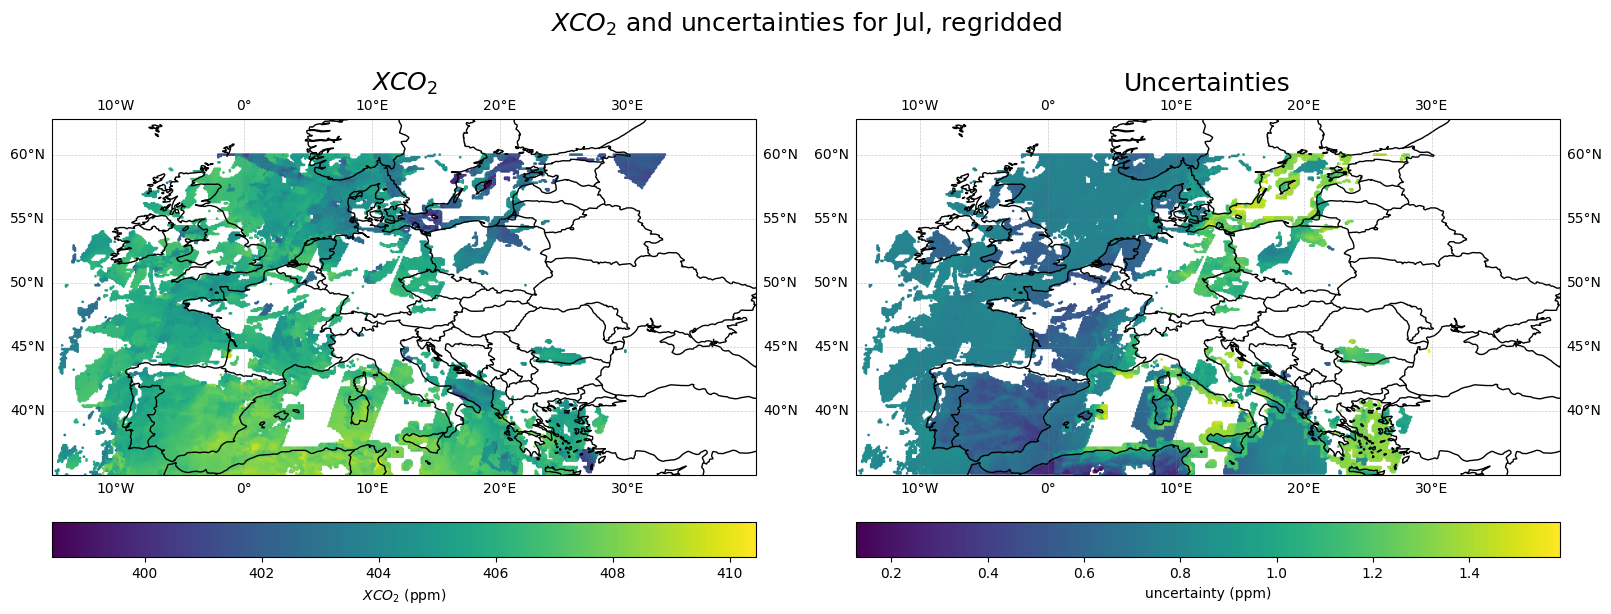

In [13]:
#Grid for plotting

res = 0.1
grid_xy = np.ogrid[aoi[0]:aoi[1]+res:res, aoi[2]:aoi[3]+res:res]
grid_x, grid_y = grid_xy[0].reshape(1,-1)[0], grid_xy[1][0]
coords = np.array([(i,j) for i in grid_x for j in grid_y])
lon_rg, lat_rg = coords[:,0], coords[:,1]

plot_data(aoi, lon_rg, lat_rg, date, xco2_1month, data2=uncertainties_1month, title1=f"$XCO_2$", title2="Uncertainties",
            label1='$XCO_2$ (ppm)', label2='uncertainty (ppm)', title = f'$XCO_2$ and uncertainties for {month}, regridded') 
            #savefig=DATA_PATH+f'uncertainties_regridded_{month}.png')


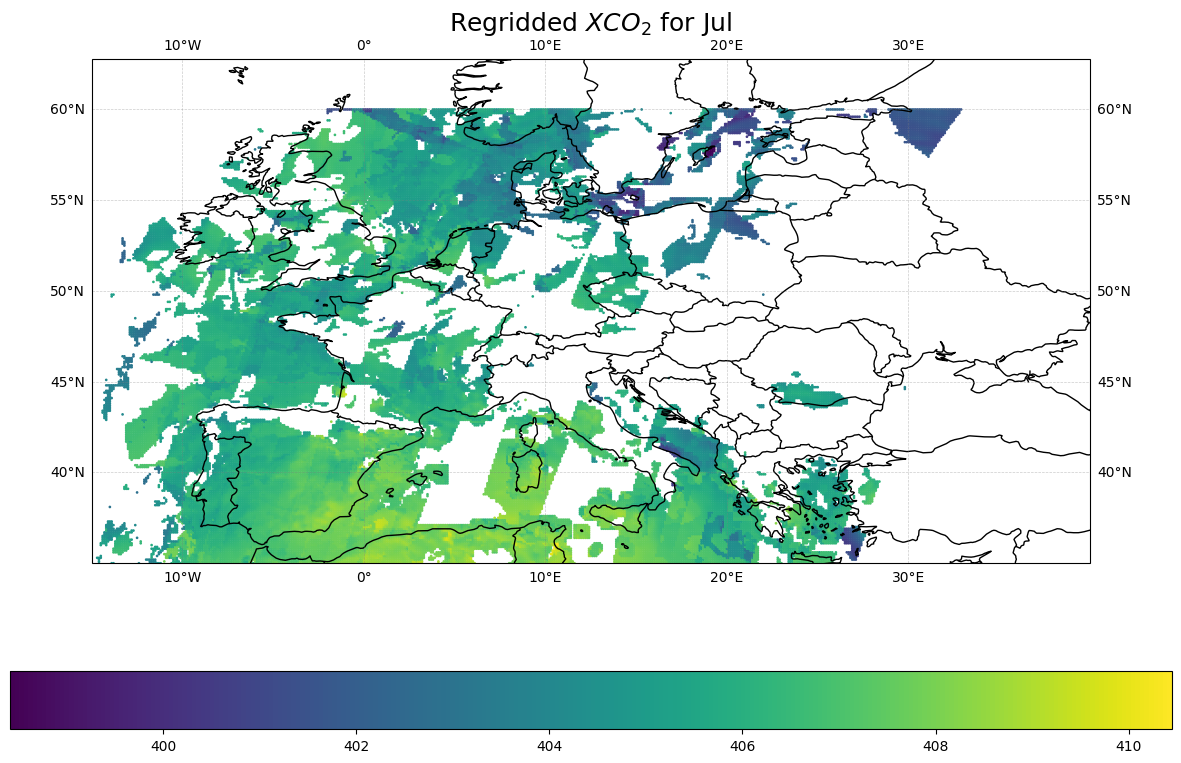

In [5]:
aux.plot_data(aoi, lon_rg, lat_rg, date,
            xco2_1month, title1=f'Regridded $XCO_2$ for {month}',
            label1='$XCO_2$ (ppm)') 
            #savefig=DATA_PATH+f'uncertainties_regridded_{month}.png')
            

## 3. Variogram analysis and covariance matrix

### 3.1 Prepare data for variogram analysis

In [5]:
# change accordingly
#uncertainties = uncertainties_rg
#period = '1day'
uncertainties = uncertainties_1month
period = '1month'

In [6]:
#create grid
res = 0.1
grid_xy = np.ogrid[aoi[0]:aoi[1]+res:res, aoi[2]:aoi[3]+res:res]
grid_x, grid_y = grid_xy[0].reshape(1,-1)[0], grid_xy[1][0]
coords = np.array([(i,j) for i in grid_x for j in grid_y])
lon_rg, lat_rg = coords[:,0], coords[:,1]


# save data to a pandas dataframe
data = {'lon': lon_rg, 
        'lat': lat_rg, 
        'uncertainties': uncertainties}
df = pd.DataFrame(data)

# remove rows with NaN values
df = df.dropna()

df.reset_index(drop=True, inplace=True)
df.sort_values(by=['lon', 'lat'], inplace=True)

df

,lon,lat,uncertainties
0,-14.7,35.3,0.838072
1,-14.6,35.1,0.833818
2,-14.6,35.2,0.835531
3,-14.6,35.3,0.836780
4,-14.5,35.3,0.835229
...,...,...,...
47875,28.3,39.4,0.998091
47876,28.3,39.5,0.989966
47877,28.4,39.5,1.007876
47878,29.8,44.6,1.588343


# Check skewness

Skewness with absolute value larger than 1 (in the presence of outliers: larger than .5) indicates problems

In [13]:
from scipy.stats import skew
skew(df['uncertainties'])

-0.01700136066035699

(array([   38.,   484.,  4017., 10214., 22227.,  2244.,  2754.,  3161.,
         2566.,   175.]),
 array([0.12581442, 0.27206732, 0.41832021, 0.56457311, 0.71082601,
        0.8570789 , 1.0033318 , 1.14958469, 1.29583759, 1.44209049,
        1.58834338]),
 <BarContainer object of 10 artists>)

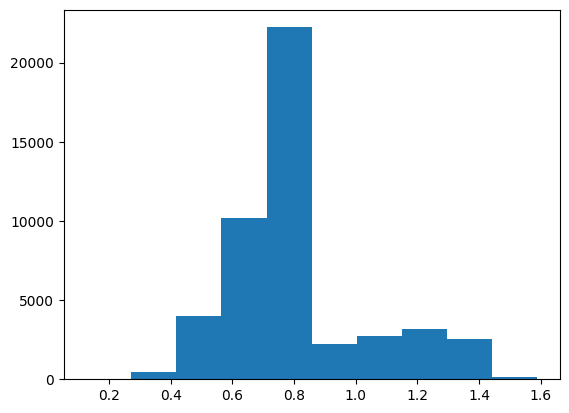

In [14]:
fig, ax = plt.subplots()
ax.hist(uncertainties)

{'whiskers': [<matplotlib.lines.Line2D at 0x7fe00e222f80>,
 'caps': [<matplotlib.lines.Line2D at 0x7fe00e2234c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fe00e222ce0>],
 'medians': [<matplotlib.lines.Line2D at 0x7fe00e223a00>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fe00e223ca0>],
 'means': []}

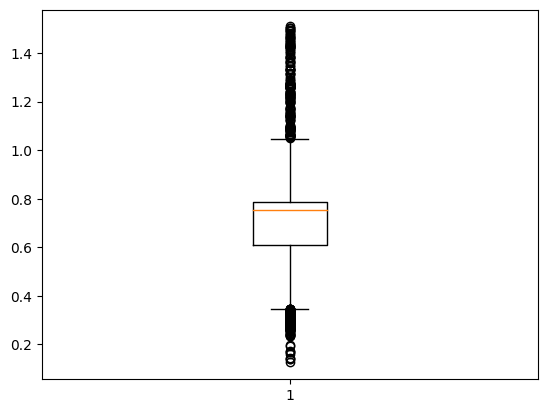

In [15]:
fig, ax = plt.subplots()
ax.boxplot(df['uncertainties'])

In [8]:
CRS("EPSG:4326")


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [19]:
CRS("EPSG:3035")

<Projected CRS: EPSG:3035>
Name: ETRS89-extended / LAEA Europe
Axis Info [cartesian]:
- Y[north]: Northing (metre)
- X[east]: Easting (metre)
Area of Use:
- name: Europe - European Union (EU) countries and candidates. Europe - onshore and offshore: Albania; Andorra; Austria; Belgium; Bosnia and Herzegovina; Bulgaria; Croatia; Cyprus; Czechia; Denmark; Estonia; Faroe Islands; Finland; France; Germany; Gibraltar; Greece; Hungary; Iceland; Ireland; Italy; Kosovo; Latvia; Liechtenstein; Lithuania; Luxembourg; Malta; Monaco; Montenegro; Netherlands; North Macedonia; Norway including Svalbard and Jan Mayen; Poland; Portugal including Madeira and Azores; Romania; San Marino; Serbia; Slovakia; Slovenia; Spain including Canary Islands; Sweden; Switzerland; Türkiye (Turkey); United Kingdom (UK) including Channel Islands and Isle of Man; Vatican City State.
- bounds: (-35.58, 24.6, 44.83, 84.73)
Coordinate Operation:
- name: Europe Equal Area 2001
- method: Lambert Azimuthal Equal Area
Datum: Eur

In [7]:
#convert lon, lat to x,y coordinates
# NOTE: the projection can be changed to the one that fits the region of interest
inProj = CRS("EPSG:4326") # WGS84
outProj = CRS("EPSG:3035")
transformer = Transformer.from_crs(inProj, outProj, always_xy=True)
x, y = transformer.transform(df["lon"].values, df["lat"].values)
# Add the UTM coordinates to the dataframe
df['x'] = x
df['y'] = y

df.head()

,lon,lat,uncertainties,x,y
0,-14.7,35.3,0.838072,2.094359e+06,1.721789e+06
1,-14.6,35.1,0.833818,2.096938e+06,1.697640e+06
2,-14.6,35.2,0.835531,2.099979e+06,1.708262e+06
3,-14.6,35.3,0.836780,2.103025e+06,1.718884e+06
4,-14.5,35.3,0.835229,2.111695e+06,1.715990e+06


### 3.2 Variogram analysis

In [17]:
# calculate maximum distance of the aoi
southwest_corner = (aoi[2], aoi[0])  # (min_lat, min_lon)
northeast_corner = (aoi[3], aoi[1])  # (max_lat, max_lon)
max_extent = geodesic(southwest_corner, northeast_corner).meters
print(f'{max_extent/1000} km')

4787.441587111274 km


In [13]:
onedeg_lat = geodesic((45.0, 10.0), (45.1, 10.0)).meters
onedeg_lat/1000

11.113275453250631

In [36]:
onedeg_lon = geodesic((45.0, 10.0), (45.0, 10.1)).meters
onedeg_lon/1000

7.884683009020227

In [16]:
max_extent/6

797906.9311852123

In [8]:
# calculate the empirical variogram
coordinates = df[['x', 'y']].values  # UTM coordinates
values = df['uncertainties'].values  # variable of interest

# define the parameters for the variogram
model = 'stable'
maxlag = 600000 #850000 #max_extent/6   #500000
n_lags = 20 #15

estimator="matheron"
V = Variogram(coordinates, values, estimator=estimator, model=model, maxlag=maxlag, n_lags=n_lags)

In [11]:
print(V)

stable Variogram
----------------
Estimator:         cressie
Effective Range:   800000.00
Sill:              0.03
Nugget:            0.00
        


/home/pietaril/.local/lib/python3.10/site-packages/skgstat/plotting/variogram_plot.py:123: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


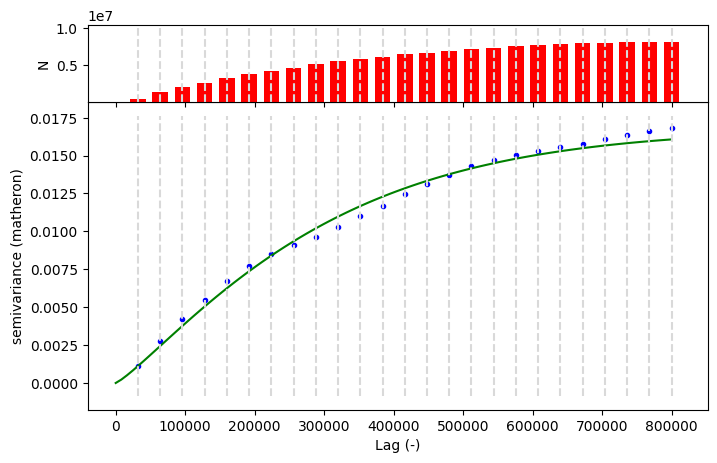

In [20]:
OUT_PATH = "/home/pietaril/Documents/plots/variogram_CO2M/"

# save and plot the variogram
V.plot()
# save in output path
#plt.savefig(f'{OUT_PATH}variogram_west_{month}_{estimator}_{model}_{int(maxlag/1000)}km_{n_lags}_lags.png')

V.plot()
plt.close()

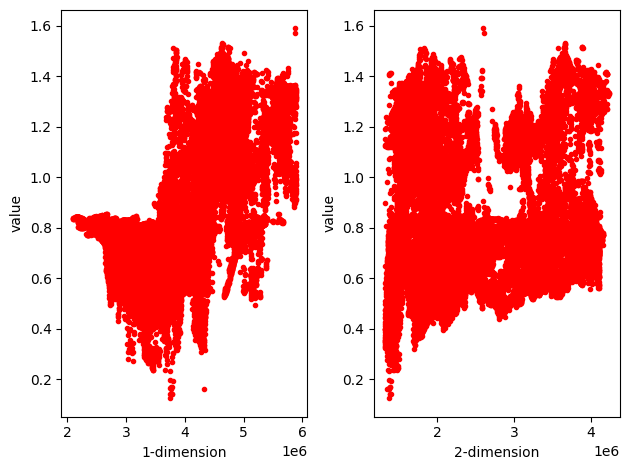

In [15]:
fig, axs = plt.subplots(1,2)
im = V.location_trend(axes=axs, show=False, add_trend_line=True)
plt.show()

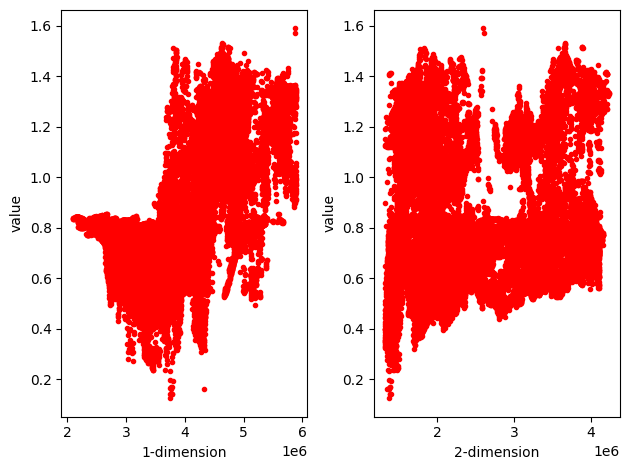

In [16]:
im

# Variogram of log-transform

In [7]:
# calculate the empirical variogram
coordinates = df[['x', 'y']].values  # UTM coordinates
values = np.log(df['uncertainties'].values)  # variable of interest

# define the parameters for the variogram
model = 'stable'
maxlag = 800000 #850000 #max_extent/6   #500000
n_lags = 25 #15

estimator="matheron"
V = Variogram(coordinates, values, estimator=estimator, model=model, maxlag=maxlag, n_lags=n_lags)

/home/pietaril/.local/lib/python3.10/site-packages/skgstat/plotting/variogram_plot.py:123: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


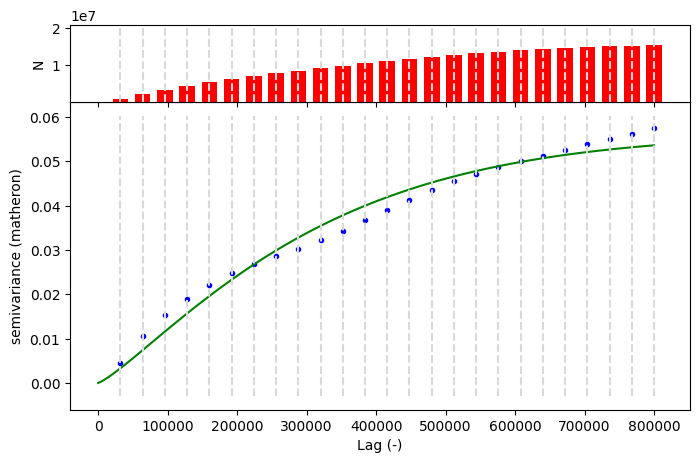

In [8]:
OUT_PATH = "/home/pietaril/Documents/plots/variogram_CO2M/"

# save and plot the variogram
V.plot()
# save in output path
plt.savefig(f'{OUT_PATH}log_variogram_{month}_{estimator}_{model}_{int(maxlag/1000)}km_{n_lags}_lags.png')

V.plot()
plt.close()

In [13]:
V.describe().get('effective_range')

799999.999286317

/home/pietaril/.local/lib/python3.10/site-packages/skgstat/plotting/variogram_dd_plot.py:46: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


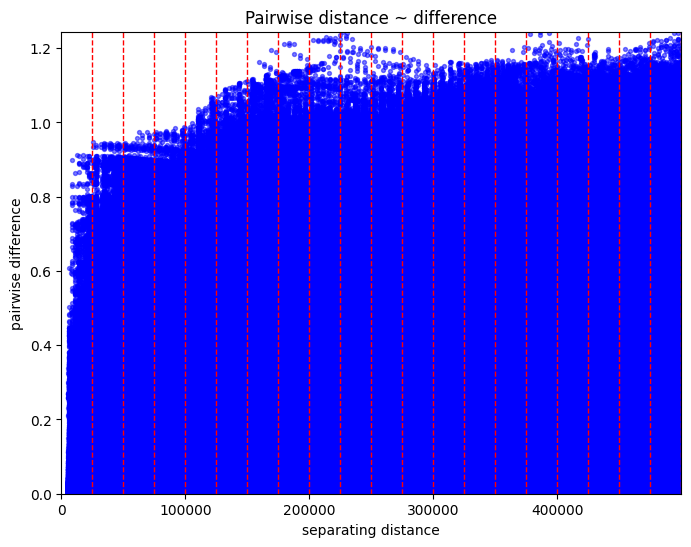

Error in callback <function flush_figures at 0x7f0d6e4b9d80> (for post_execute):


KeyboardInterrupt: 

In [18]:
V.distance_difference_plot()

In [14]:
V.bins

array([ 33999.99998733,  67999.99997465, 101999.99996198, 135999.9999493 ,
       169999.99993663, 203999.99992395, 237999.99991128, 271999.99989861,
       305999.99988593, 339999.99987326, 373999.99986058, 407999.99984791,
       441999.99983523, 475999.99982256, 509999.99980989, 543999.99979721,
       577999.99978454, 611999.99977186, 645999.99975919, 679999.99974651,
       713999.99973384, 747999.99972117, 781999.99970849, 815999.99969582,
       849999.99968314])

In [21]:
#min, mean and max differences within each group
for i, group in enumerate(V.lag_classes()):
    print('[Group %d]: elements: %d min %.2f, mean %.2f, max %.2f ' % (i, len(group), np.min(group), np.mean(group), np.max(group)))

[Group 0]: elements: 692768 min 0.00, mean 0.04, max 0.83 
[Group 1]: elements: 1893637 min 0.00, mean 0.06, max 0.96 
[Group 2]: elements: 2902899 min 0.00, mean 0.08, max 1.05 
[Group 3]: elements: 3811273 min 0.00, mean 0.09, max 1.25 
[Group 4]: elements: 4777484 min 0.00, mean 0.10, max 1.09 
[Group 5]: elements: 5518946 min 0.00, mean 0.11, max 1.22 
[Group 6]: elements: 6183189 min 0.00, mean 0.11, max 1.24 
[Group 7]: elements: 7028921 min 0.00, mean 0.12, max 1.19 
[Group 8]: elements: 7651407 min 0.00, mean 0.13, max 1.19 
[Group 9]: elements: 8146736 min 0.00, mean 0.13, max 1.18 
[Group 10]: elements: 8828331 min 0.00, mean 0.14, max 1.22 
[Group 11]: elements: 9422526 min 0.00, mean 0.14, max 1.24 
[Group 12]: elements: 9840259 min 0.00, mean 0.15, max 1.24 
[Group 13]: elements: 10392086 min 0.00, mean 0.16, max 1.27 
[Group 14]: elements: 10989806 min 0.00, mean 0.16, max 1.37 
[Group 15]: elements: 11432758 min 0.00, mean 0.17, max 1.38 
[Group 16]: elements: 11840848 m

In [20]:
V.model = "stable"
V.n_lags = 30

The Variogram class has several goodness of fit measures to help on assessing the fit.

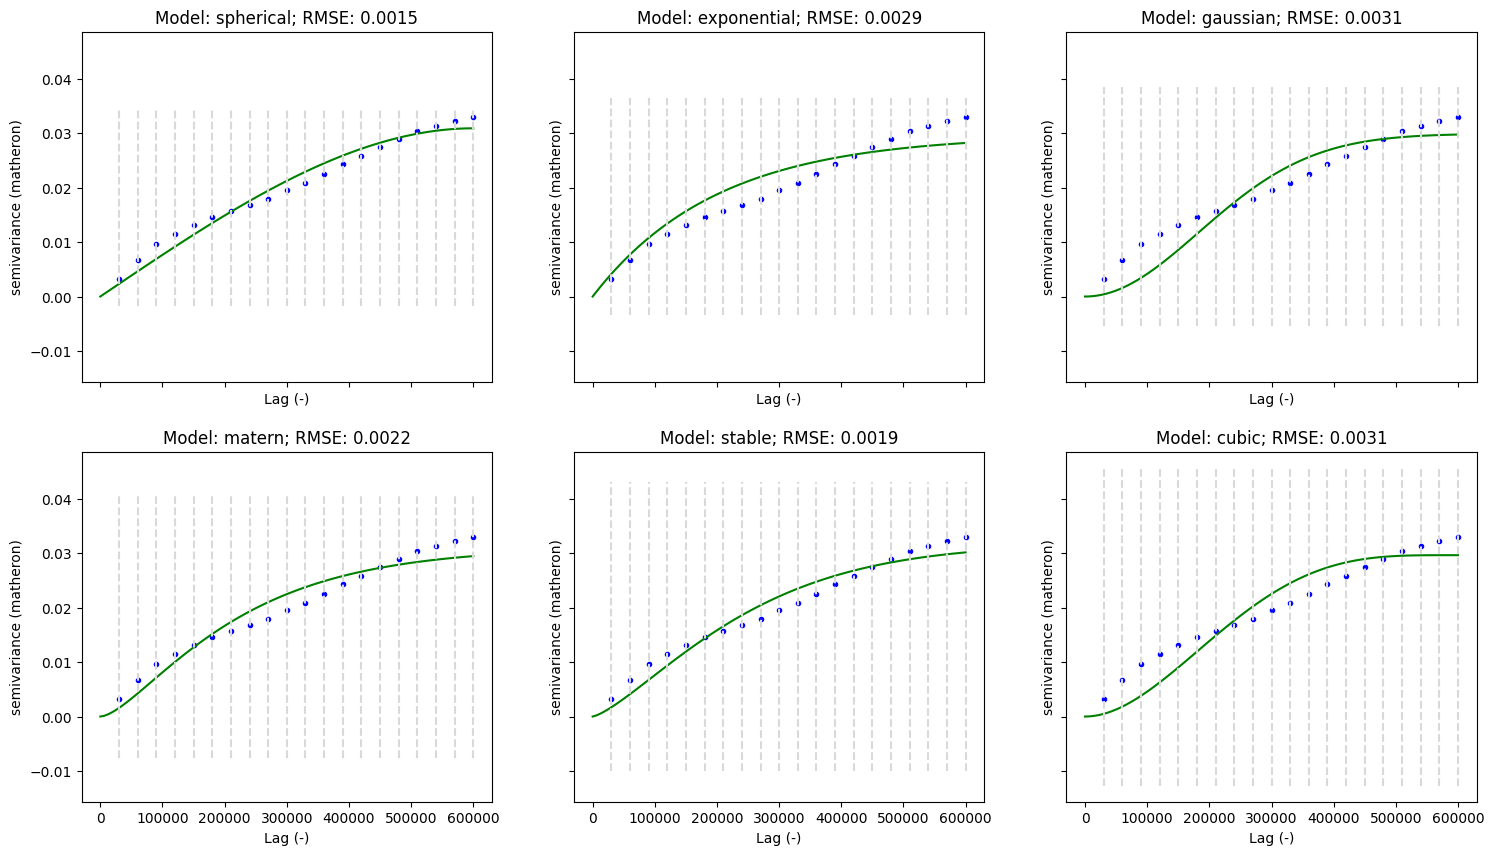

In [22]:
# visualization of the variograms for different models
fig, _a = plt.subplots(2,3, figsize=(18, 10), sharex=True, sharey=True)
axes = _a.flatten()
for i, model in enumerate(('spherical', 'exponential', 'gaussian', 'matern', 'stable', 'cubic')):
    V.model = model
    V.plot(axes=axes[i], hist=False, show=False)
    axes[i].set_title('Model: %s; RMSE: %.4f' % (model, V.rmse))
fig.suptitle(f"{month} variogram of domain ")
plt.savefig(f'{OUT_PATH}variogram_{month}_comparison_{int(maxlag/1000)}km_{n_lags}_lags.png')
#plt.close()

In [17]:
V.lag_groups()

array([0, 0, 0, ..., 0, 0, 0])

# Directional variogram

In [7]:
# calculate the empirical variogram
coordinates = df[['x', 'y']].values  # UTM coordinates
values = df['uncertainties'].values  # variable of interest
#model = "stable"

# define the parameters for the variogram

maxlag = 600000 #850000 #max_extent/6   #500000
n_lags = 20 #15

Vnorth = DirectionalVariogram(coordinates, values, azimuth=90, tolerance=90, maxlag=maxlag, n_lags=n_lags)
Veast =  DirectionalVariogram(coordinates, values, azimuth=0, tolerance=90, maxlag=maxlag, n_lags=n_lags)
pd.DataFrame({'north':Vnorth.describe(), 'east': Veast.describe()})

: 

Plot the directional empirical variograms

In [ ]:
fix, ax = plt.subplots(1,1,figsize=(8,6))

ax.plot(Vnorth.bins, Vnorth.experimental, '.--r', label='North-South')
ax.plot(Veast.bins, Veast.experimental, '.--b', label='East-West')
ax.set_xlabel('lag [m]')
ax.set_ylabel('semi-variance (matheron)')

plt.legend(loc='upper left')
plt.savefig(f'{OUT_PATH}directional_variogram_{month}_{int(maxlag/1000)}km_{n_lags}_lags.png')
plt.close()

### 3.3 Construct the covariance matrix

It seems that the stable model is the best fit for the empirical variogram. This is given by $$\gamma(h)=C\left(1-\exp\left(-\left(\frac{h}{a}\right)^\alpha\right)\right),$$
where
- $C$ is the sill (the value where the variogram plateaus, representing total variance),
- $h$ is the distance (lag) between points,
- $a$ is the range (the distance at which the variogram reaches the sill),
- $\alpha$ is the stability parameter that controls the shape of the curve (with $0<\alpha\leq 2$.

We build a weight matrix from the stable model to account for spatial correlation wrt distance between points. We subtract the semivariance from the sill, as the covariance at lag 0 is the sill itself:
$$W(h)=C-\gamma(h).$$

We asume that the model is 'stable'.

In [30]:
V.model = 'stable'

sill = V.describe()['sill']
max_range = V.describe()['effective_range']
alpha = V.describe()['shape']

sill, max_range, alpha

(0.023700270823690653, 499999.9978423866, 1.417802342832251)

In [31]:
distances = aux.calculate_distances(coordinates)
W = aux.build_weight_matrix(distances, sill, max_range, alpha)

: 

In [22]:
# compute covariance matrix
n = len(df)
cov_matrix = np.zeros((n,n))

for i in range(n):
    for j in range(n):
        if i <= j:
            cov_matrix[i, j] = W[i, j]*df.uncertainties[i]*df.uncertainties[j]
            cov_matrix[j, i] = cov_matrix[i, j]

In [23]:
# analyize the covariance matrix

# check symmetry
is_symmetric = np.allclose(cov_matrix, cov_matrix.T)

# compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# check positive semidefiniteness
is_positive_semidefinite = np.all(eigenvalues >= 0)

# diagonal elements (variances)
variances = np.diag(cov_matrix)

# determinant and  condition number
determinant = np.linalg.det(cov_matrix)
condition_number = np.linalg.cond(cov_matrix)

print(f"Is symmetric: {is_symmetric}")
print(f"Is positive semidefinite: {is_positive_semidefinite}")
print(f"Variances: {variances}")
print(f"Determinant: {determinant}")
print(f"Condition number: {condition_number}")

Is symmetric: True
Is positive semidefinite: False
Variances: [3.98349969e-05 2.19872783e-04 5.51472981e-05 ... 1.44513404e-01
 1.37412441e-01 1.35904555e-01]
Determinant: 0.0
Condition number: 4.4723974144020324e+19


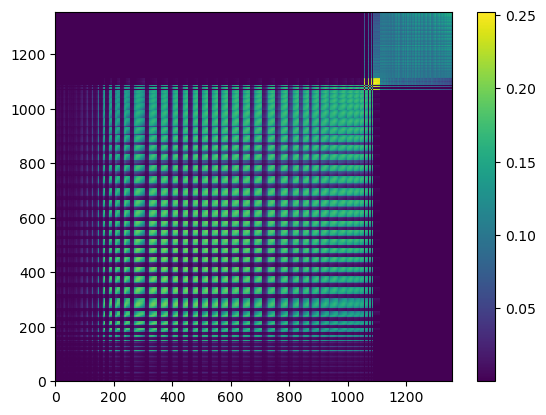

In [24]:
plt.pcolor(cov_matrix)
plt.colorbar()

plt.show()

In [90]:
# recover lon, lat from the covariance matrix

i, j = 0, 1 # example

longitude_i, latitude_i = df.loc[i, 'lon'], df.loc[i, 'lat']
longitude_j, latitude_j = df.loc[j, 'lon'], df.loc[j, 'lat']
